##**iTransformer (State-of-the-Art Research)**

### **Concept**
The **iTransformer** (Inverted Transformer) is a cutting-edge architecture proposed in 2024. It fundamentally "flips" the standard Transformer logic to better handle multivariate time-series data like ours.

### **The "Inversion" Mechanism**
* **Standard Transformer:** Treats **Time Steps** as tokens (e.g., looking at temporal patterns first).
* **iTransformer:** Treats **Variables** as tokens. It embeds the entire time series of "Rainfall" as one token and "Storage" as another.
    * *Result:* The attention mechanism learns the complex, non-linear relationships **between variables** (e.g., How exactly does Rainfall drive Storage?) rather than just temporal dependencies.



### **Hypothesis**
We test if this "variate-centric" approach can capture the hydrological physics better than standard RNNs (LSTM), or if the model complexity is too high for our dataset size.

**Import Required libraries and Modules**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import sys

**Setup & Data Loading**

In [4]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/EDI-III Project/Data/Processed Data'
else:
    BASE_PATH = '.'

file_path = os.path.join(BASE_PATH, 'Chembarambakkam.csv')
print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if df.index.duplicated().any():
        print(f"Warning: Found {df.index.duplicated().sum()} duplicate dates. Keeping the first occurrence.")
        df = df[~df.index.duplicated(keep='first')]

    df = df.asfreq('D')

    df = df.ffill()
except FileNotFoundError:
    print("Error: File not found. Please run the Data Processing script first.")
    sys.exit()

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/EDI-III Project/Data/Processed Data/Chembarambakkam.csv


In [5]:
data = df.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Sequence Length (Lookback)
SEQ_LENGTH = 10

def create_sequences(dataset, seq_length):
    X, y = [], []
    target_idx = df.columns.get_loc('Storage (mcft)')
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length, target_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Train/Test Split (Same 730 days)
test_days = 730
train_size = len(X) - test_days
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Input Shape: {X_train.shape} (Samples, Time Steps, Variates)")

Input Shape: (6802, 10, 26) (Samples, Time Steps, Variates)


In [6]:
print("\nBuilding iTransformer Model...")

def build_itransformer(input_shape, d_model=64, num_heads=4):
    inputs = layers.Input(shape=input_shape) # (Time, Variates)

    x = layers.Permute((2, 1))(inputs) # Output: (Variates, Time)

    x = layers.Dense(d_model)(x) # Output: (Variates, d_model)

    att_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    x = layers.Add()([x, att_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ffn_output = layers.Dense(d_model * 2, activation='relu')(x)
    ffn_output = layers.Dense(d_model)(ffn_output)
    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs, name="iTransformer")
    return model

model = build_itransformer(input_shape=(X_train.shape[1], X_train.shape[2]))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


Building iTransformer Model...


Model: "iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 26)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 26, 10)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 26, 64)    │        704 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 26, 64)    │     66,368 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 26, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 26, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 26, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 26, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 26, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 26, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1664)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1664)      │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │      1,665 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,569 (334.25 KB)

 Trainable params: 85,569 (334.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 1.0199 - val_loss: 0.0093
Epoch 2/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0551 - val_loss: 0.0039
Epoch 3/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0096 - val_loss: 0.0031
Epoch 4/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - val_loss: 0.0028
Epoch 5/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0046 - val_loss: 0.0016
Epoch 6/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0034 - val_loss: 0.0011
Epoch 7/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0032 - val_loss: 5.8188e-04
Epoch 8/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - val_loss: 0.0022
Epoch 9/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 10/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - val_loss: 8.6999e-04
Epoch 11/40
426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020 - val_loss: 4.1123e-04
Epoch 12/40
426/426 ━━━━━━━━━━━━━━━━━━

In [8]:
# Make predictions
y_pred_scaled = model.predict(X_test)

target_idx = df.columns.get_loc('Storage (mcft)')

y_test_full_features = np.zeros((len(y_test), scaled_data.shape[1]))
y_test_full_features[:, target_idx] = y_test
inversed_actuals = scaler.inverse_transform(y_test_full_features)[:, target_idx]

# Inverse transform the predictions
y_pred_full_features = np.zeros((len(y_pred_scaled), scaled_data.shape[1]))
y_pred_full_features[:, target_idx] = y_pred_scaled.flatten() # Ensure y_pred_scaled is 1D
inversed_predictions = scaler.inverse_transform(y_pred_full_features)[:, target_idx]


# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(inversed_actuals, inversed_predictions))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(inversed_actuals, inversed_predictions)

# MAPE (Mean Absolute Percentage Error)
# Adding epsilon (1e-10) to avoid division by zero
mape = np.mean(np.abs((inversed_actuals - inversed_predictions) / (inversed_actuals + 1e-10))) * 100

# R-squared (R2)
r2 = r2_score(inversed_actuals, inversed_predictions)

print(f"\n{'='*30}")
print(f"iTransformer Model")
print(f"{'='*30}")
print(f"RMSE : {rmse:.2f} mcft")
print(f"MAE  : {mae:.2f} mcft")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")
print(f"{'='*30}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step

iTransformer Model
RMSE : 49.33 mcft
MAE  : 30.87 mcft
MAPE : 1.23 %
R²   : 0.9920


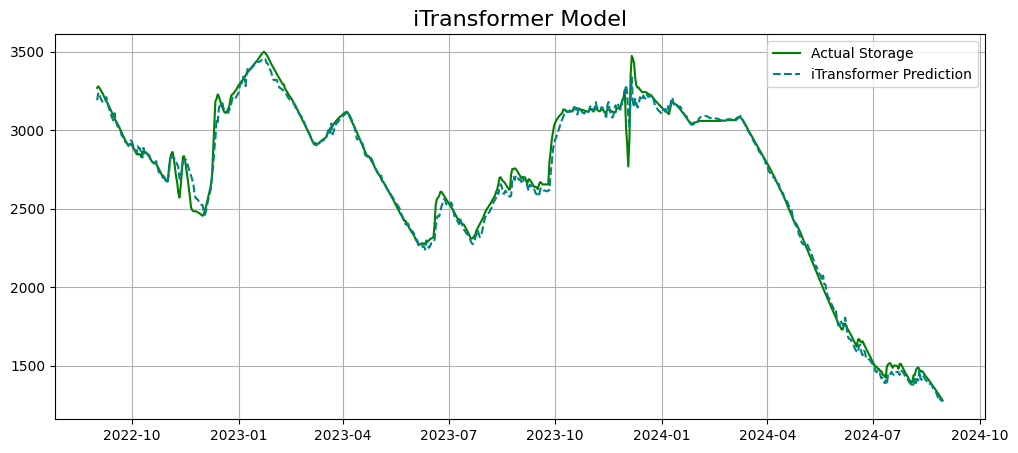

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[-test_days:], inversed_actuals, label='Actual Storage', color='green')
plt.plot(df.index[-test_days:], inversed_predictions, label='iTransformer Prediction', color='teal', linestyle='--')
plt.title('iTransformer Model', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()